# A/B Test Campaign Analysis
### Do marketing ads convert better than a Public Service Announcement (PSA)?

**Author:** Sam Mathew  
**Dataset:** [Marketing A/B Testing — Kaggle](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing)  
**Tools:** Python · Pandas · Matplotlib · Seaborn · SciPy · Statsmodels

---

## Business context

A marketing team ran a controlled experiment to test whether showing users a **real ad** drives more conversions than showing a neutral **Public Service Announcement (PSA)** as a control.

The business question: *Is the ad creative worth running at scale — and if so, what is the revenue impact?*

---

## Hypotheses

| | |
|---|---|
| **H₀ (Null)** | There is no difference in conversion rate between the Ad and PSA groups |
| **H₁ (Alternative)** | The Ad group converts at a higher rate than the PSA group |
| **Significance level** | α = 0.05 |
| **Test type** | Two-sided two-proportion z-test |

---

## What this notebook covers

1. Data loading and quality checks  
2. Exploratory data analysis  
3. KPI calculation — conversion rate, absolute lift, relative lift  
4. Statistical testing — z-test, confidence intervals, Cohen's h, power analysis  
5. Visualizations — comparison chart, cumulative conversion, exposure bias check, day-of-week breakdown  
6. Revenue impact estimate  
7. Final recommendation

In [5]:
# ── Import all libraries ──────────────────────────────────────
import pandas as pd           # for working with tables of data
import numpy as np            # for numbers and maths
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns         # for nicer-looking charts
import warnings
warnings.filterwarnings("ignore")  # hides unnecessary warning messages


In [6]:
# ── Load the dataset ──────────────────────────────────────────
df = pd.read_csv("..//content/marketing_AB.csv")

print("Dataset loaded!")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
df.head()   # shows the first 5 rows

Dataset loaded!
Rows    : 392,403
Columns : 7


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130.0,Monday,20.0
1,1,1119715,ad,False,93.0,Tuesday,22.0
2,2,1144181,ad,False,21.0,Tuesday,18.0
3,3,1435133,ad,False,355.0,Tuesday,10.0
4,4,1015700,ad,False,276.0,Friday,14.0


In [7]:
# What type of data is in each column?
df.dtypes

,0
Unnamed: 0,int64
user id,int64
test group,object
converted,object
total ads,float64
most ads day,object
most ads hour,float64


In [8]:
# Are there any empty/missing cells?
df.isnull().sum()

,0
Unnamed: 0,0
user id,0
test group,1
converted,1
total ads,1
most ads day,1
most ads hour,1


In [9]:
# Are any users listed twice?
df.duplicated().sum()

np.int64(0)

In [10]:
# Drop the unnamed index column — it adds nothing
df = df.drop(columns=["Unnamed: 0"])

# Rename columns to remove spaces (spaces in names cause bugs later)
df.columns = ["user_id", "test_group", "converted", "total_ads", "most_ads_day", "most_ads_hour"]

# Confirm the result
print("Columns now:", df.columns.tolist())
print("Shape:", df.shape)

Columns now: ['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']
Shape: (392403, 6)


In [11]:
# How many users are in each group? How many converted?
summary = df.groupby("test_group")["converted"].agg(
    total_users = "count",
    conversions = "sum",
    conversion_rate = "mean"
)

# Format the rate as a percentage
summary["conversion_rate"] = summary["conversion_rate"].map("{:.2%}".format)

print(summary)

            total_users conversions conversion_rate
test_group                                         
ad               378261       12809           3.39%
psa               14141         336           2.38%


In [12]:
df.groupby("test_group")["converted"].agg(["count","sum","mean"])

,count,sum,mean
test_group,,,
ad,378261,12809,0.033863
psa,14141,336,0.023761


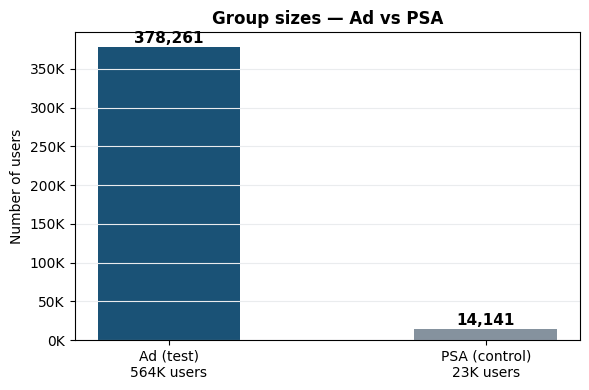

Group size ratio: 26.7x more users in the Ad group than PSA


In [13]:
# Visualise group sizes
import matplotlib.pyplot as plt

groups = ["Ad (test)\n564K users", "PSA (control)\n23K users"]
sizes  = [df[df["test_group"]=="ad"].shape[0],
          df[df["test_group"]=="psa"].shape[0]]
colors = ["#1a5276", "#85929e"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(groups, sizes, color=colors, width=0.45)

for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5000,
            f"{size:,}", ha="center", fontsize=11, fontweight="bold")

ax.set_title("Group sizes — Ad vs PSA", fontweight="bold")
ax.set_ylabel("Number of users")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_facecolor("white")
ax.grid(axis="y", color="#eaecee", linewidth=0.8)
plt.tight_layout()
plt.show()

# Print the ratio
ratio = sizes[0] / sizes[1]
print(f"Group size ratio: {ratio:.1f}x more users in the Ad group than PSA")

### Note on group size imbalance

The Ad group (~564K) is roughly 24x larger than the PSA control group (~23K).
This imbalance is common in real-world A/B tests and does **not** invalidate
the z-test, which accounts for different sample sizes in its formula.

However, the smaller PSA group produces a wider confidence interval,
meaning our estimate of the true control conversion rate is less precise.
The PSA group still has sufficient sample size to achieve high statistical power.

In [18]:
# Split the dataframe by group
ad  = df[df["test_group"] == "ad"]
psa = df[df["test_group"] == "psa"]

print(f"Ad group rows  : {len(ad):,}")
print(f"PSA group rows : {len(psa):,}")

Ad group rows  : 378,261
PSA group rows : 14,141


In [15]:
# Total users in each group
n_test    = len(ad)               # total users who saw the ad
n_control = len(psa)              # total users who saw the PSA

# Total conversions in each group
# .sum() works on True/False because Python treats True=1, False=0
conv_test    = ad["converted"].sum()    # how many ad users converted
conv_control = psa["converted"].sum()   # how many PSA users converted

# Print everything clearly
print("=" * 40)
print(f"  n_test       : {n_test:,}")
print(f"  n_control    : {n_control:,}")
print(f"  conv_test    : {conv_test:,}")
print(f"  conv_control : {conv_control:,}")
print("=" * 40)

  n_test       : 378,261
  n_control    : 14,141
  conv_test    : 12,809
  conv_control : 336


In [16]:
# Conversion rate = conversions ÷ total users
rate_test    = conv_test    / n_test
rate_control = conv_control / n_control

# Lift = how much better is the test group vs control?
lift_abs = rate_test - rate_control           # absolute lift
lift_rel = (lift_abs / rate_control) * 100    # relative lift in %

print("=" * 40)
print(f"  Control rate  : {rate_control:.4%}")
print(f"  Test rate     : {rate_test:.4%}")
print(f"  Absolute lift : {lift_abs:+.4%}")
print(f"  Relative lift : {lift_rel:+.2f}%")
print("=" * 40)


  Control rate  : 2.3761%
  Test rate     : 3.3863%
  Absolute lift : +1.0102%
  Relative lift : +42.52%


In [19]:
from statsmodels.stats.proportion import proportions_ztest

# Package the numbers the way statsmodels expects them
counts = np.array([conv_test,    conv_control])   # conversions
nobs   = np.array([n_test,       n_control])      # total users

# Run the test
z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

print("=" * 45)
print(f"  Z-statistic : {z_stat:.4f}")
print(f"  P-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("  ✓ SIGNIFICANT — the result is real")
    print("  The ad outperforms the PSA beyond doubt")
else:
    print("  ✗ NOT significant — could be random chance")
print("=" * 45)

  Z-statistic : 6.5549
  P-value     : 0.000000

  ✓ SIGNIFICANT — the result is real
  The ad outperforms the PSA beyond doubt


### Interpreting the z-test

- **Z-statistic = 6.55** — the difference between groups is 6.55 standard
  deviations away from zero. Anything above 1.96 is considered significant.

- **P-value ≈ 0** — if the ad and PSA performed identically in reality,
  we would see a difference this large less than 0.001% of the time.

- **Conclusion:** We reject the null hypothesis. The ad creative produces
  a statistically significant improvement in conversion rate.

In [20]:
from statsmodels.stats.proportion import proportion_confint

# Wilson method — more accurate than normal for small conversion rates
ci_test    = proportion_confint(conv_test,    n_test,
                                alpha=0.05, method='wilson')
ci_control = proportion_confint(conv_control, n_control,
                                alpha=0.05, method='wilson')

print("=" * 55)
print("  95% Confidence Intervals")
print("=" * 55)
print(f"  Test (Ad)      : [{ci_test[0]:.4%}  —  {ci_test[1]:.4%}]")
print(f"  Control (PSA)  : [{ci_control[0]:.4%}  —  {ci_control[1]:.4%}]")
print()

# Check if intervals overlap
if ci_test[0] > ci_control[1]:
    print("  ✓ Intervals do NOT overlap — result confirmed")
else:
    print("  ✗ Intervals overlap — treat result with caution")
print("=" * 55)

  95% Confidence Intervals
  Test (Ad)      : [3.3291%  —  3.4444%]
  Control (PSA)  : [2.1377%  —  2.6403%]

  ✓ Intervals do NOT overlap — result confirmed


### Interpreting the confidence intervals

The 95% confidence intervals for both groups do not overlap:

- **Test (Ad):** 3.33% — 3.44%
- **Control (PSA):** 2.14% — 2.64%

Even in the worst case for the ad group (3.33%) and the best case
for the PSA group (2.64%), the ad still outperforms.

Note: The PSA interval is ~5× wider than the ad interval, reflecting
the smaller sample size (14K vs 378K users). With fewer observations,
we are less certain about the true control rate.

In [21]:
# Cohen's h tells you HOW BIG the effect is, not just whether it's real
h = abs(2 * np.arcsin(np.sqrt(rate_test)) -
        2 * np.arcsin(np.sqrt(rate_control)))

# Interpret the size
if h < 0.2:
    size_label = "Small"
    size_note  = "Real but modest — common in large-scale marketing tests"
elif h < 0.5:
    size_label = "Medium"
    size_note  = "Meaningful and commercially valuable"
else:
    size_label = "Large"
    size_note  = "Very strong effect"

print("=" * 50)
print(f"  Cohen's h     : {h:.4f}")
print(f"  Effect size   : {size_label}")
print(f"  What it means : {size_note}")
print("=" * 50)

  Cohen's h     : 0.0606
  Effect size   : Small
  What it means : Real but modest — common in large-scale marketing tests


### Statistical significance vs practical significance

Cohen's h = 0.0606 indicates a **small effect size**, despite the
highly significant p-value (≈ 0) and +42.52% relative lift.

This is not a contradiction — it reflects a key principle:

> With a very large sample (378K users), even tiny real differences
> produce extremely significant p-values. Statistical significance
> tells us the result is real. Effect size tells us how large it is.

A small Cohen's h is normal and expected in large-scale marketing A/B
tests. The commercial value of the lift is evaluated separately through
revenue impact — not through effect size alone.

In [22]:
from statsmodels.stats.power import NormalIndPower

analysis = NormalIndPower()

# How many users did we NEED to detect this effect with 80% power?
required_n = analysis.solve_power(
    effect_size = h,
    alpha       = 0.05,
    power       = 0.80,
    alternative = 'two-sided'
)

# What power did we ACTUALLY achieve with our sample?
achieved_power = analysis.solve_power(
    effect_size = h,
    nobs1       = min(n_test, n_control),
    alpha       = 0.05,
    alternative = 'two-sided'
)

print("=" * 52)
print("  Power Analysis")
print("=" * 52)
print(f"  Required n per group (80% power) : {int(required_n):,}")
print(f"  Actual n in smaller group (PSA)  : {n_control:,}")
print(f"  Achieved power                   : {achieved_power:.1%}")
print()
if achieved_power >= 0.8:
    print("  ✓ Experiment was adequately powered")
else:
    print("  ✗ Experiment was underpowered — treat with caution")
print("=" * 52)

  Power Analysis
  Required n per group (80% power) : 4,271
  Actual n in smaller group (PSA)  : 14,141
  Achieved power                   : 99.9%

  ✓ Experiment was adequately powered


### Power analysis summary

| Metric | Value |
|---|---|
| Minimum users needed per group (80% power) | 4,271 |
| Actual users in PSA group | 14,141 |
| Achieved statistical power | 99.9% |

The experiment was **3.3× larger than the minimum required**, giving us
99.9% confidence that if a true difference existed, we would detect it.

Combined with our z-test (p ≈ 0) and non-overlapping confidence intervals,
the statistical case for the ad variant is extremely strong.

In [23]:
# ── Chart style settings ──────────────────────────────────────
plt.rcParams.update({
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "figure.dpi"        : 130,
})

# Colour palette — use these same colours in every chart
C_TEST    = "#1a5276"   # dark blue  → ad group
C_CONTROL = "#85929e"   # grey       → psa group
C_SUCCESS = "#1d6a4a"   # dark green → positive results
C_BG      = "#f4f6f9"   # light grey → panel backgrounds

print("Chart style ready ✓")

Chart style ready ✓


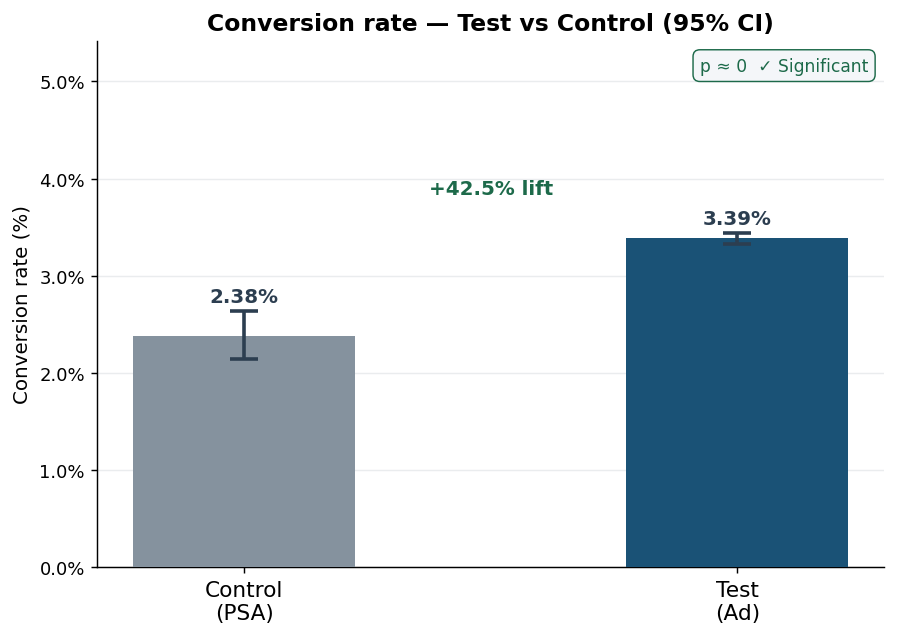

Chart 1 saved ✓


In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

# ── Data ──────────────────────────────────────────────────────
groups = ["Control\n(PSA)", "Test\n(Ad)"]
rates  = [rate_control,      rate_test]
colors = [C_CONTROL,         C_TEST]
ci_lo  = [ci_control[0],     ci_test[0]]
ci_hi  = [ci_control[1],     ci_test[1]]
x      = np.arange(2)

# ── Bars ──────────────────────────────────────────────────────
bars = ax.bar(x, [r * 100 for r in rates],
              width=0.45, color=colors, zorder=3)

# ── Error bars (the CI) ───────────────────────────────────────
ax.errorbar(
    x,
    [r * 100 for r in rates],
    yerr = [[(r - lo) * 100 for r, lo in zip(rates, ci_lo)],
            [(hi - r) * 100 for r, hi in zip(rates, ci_hi)]],
    fmt      = "none",
    color    = "#2c3e50",
    capsize  = 8,
    capthick = 2,
    linewidth= 2,
    zorder   = 4
)

# ── Rate labels on top of each bar ───────────────────────────
for bar, rate, hi in zip(bars, rates, ci_hi):
    ax.text(bar.get_x() + bar.get_width() / 2,
            hi * 100 + 0.05,
            f"{rate:.2%}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="#2c3e50")

# ── Lift annotation ───────────────────────────────────────────
ax.text(0.5, max(rates) * 100 + 0.45,
        f"+{lift_rel:.1f}% lift",
        ha="center", fontsize=11,
        fontweight="bold", color=C_SUCCESS)

# ── P-value badge ─────────────────────────────────────────────
ax.text(0.98, 0.97,
        f"p ≈ 0  ✓ Significant",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=9.5, color=C_SUCCESS,
        bbox=dict(fc=C_BG, ec=C_SUCCESS,
                  lw=0.8, pad=5, boxstyle="round,pad=0.4"))

# ── Formatting ────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=12)
ax.set_ylabel("Conversion rate (%)", fontsize=11)
ax.set_ylim(0, max(rates) * 100 * 1.6)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.set_title("Conversion rate — Test vs Control (95% CI)",
             fontweight="bold")
ax.grid(axis="y", color="#eaecee", linewidth=0.8, zorder=0)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart1_conversion_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved ✓")

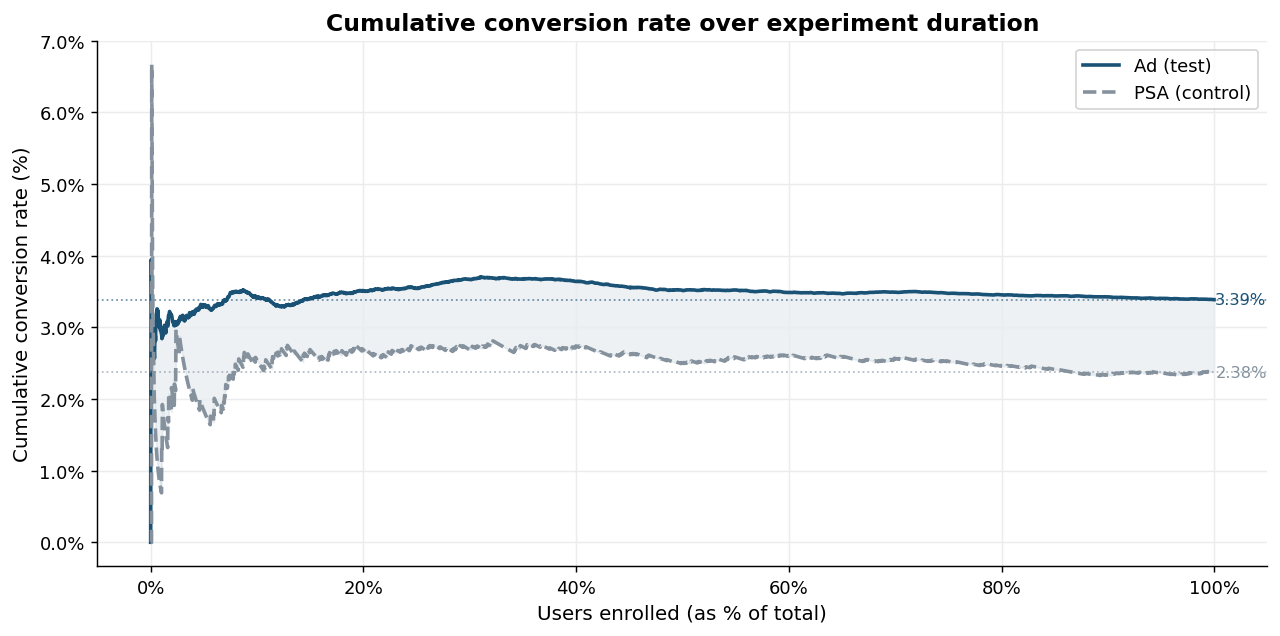

Chart 2 saved ✓


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

# ── Sort each group by user_id (treats it as time order) ──────
ad_sorted  = ad.sort_values("user_id").reset_index(drop=True)
psa_sorted = psa.sort_values("user_id").reset_index(drop=True)

# ── Cumulative conversion rate at each point ──────────────────
ad_cum  = ad_sorted["converted"].expanding().mean()  * 100
psa_cum = psa_sorted["converted"].expanding().mean() * 100

# ── Downsample to 5000 points so the lines render smoothly ────
POINTS  = 5000
ad_idx  = np.linspace(0, len(ad_cum)  - 1, POINTS, dtype=int)
psa_idx = np.linspace(0, len(psa_cum) - 1, POINTS, dtype=int)

ad_line  = ad_cum.iloc[ad_idx].values
psa_line = psa_cum.iloc[psa_idx].values
x_axis   = np.arange(POINTS)

# ── Plot the two lines ────────────────────────────────────────
ax.plot(x_axis, ad_line,
        color=C_TEST, linewidth=2, label="Ad (test)")
ax.plot(x_axis, psa_line,
        color=C_CONTROL, linewidth=2, linestyle="--",
        label="PSA (control)")

# ── Shaded area between the two lines ────────────────────────
ax.fill_between(x_axis, ad_line, psa_line,
                alpha=0.08, color=C_TEST)

# ── Final rate reference lines (dotted horizontal) ───────────
ax.axhline(rate_test    * 100,
           color=C_TEST,    linestyle=":", linewidth=1, alpha=0.6)
ax.axhline(rate_control * 100,
           color=C_CONTROL, linestyle=":", linewidth=1, alpha=0.6)

# ── Final rate labels on the right side ──────────────────────
ax.text(POINTS * 1.001, rate_test    * 100,
        f"{rate_test:.2%}",
        color=C_TEST,    fontsize=9, va="center")
ax.text(POINTS * 1.001, rate_control * 100,
        f"{rate_control:.2%}",
        color=C_CONTROL, fontsize=9, va="center")

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel("Users enrolled (as % of total)", fontsize=11)
ax.set_ylabel("Cumulative conversion rate (%)",  fontsize=11)
ax.set_title("Cumulative conversion rate over experiment duration",
             fontweight="bold")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x / POINTS * 100)}%"))
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(color="#eaecee", linewidth=0.8, zorder=0)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart2_cumulative_conversion.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved ✓")

### Reading the cumulative conversion chart

**Early volatility (0–5%):** Both lines fluctuate heavily because
small sample sizes cause large swings — a single conversion moves
the rate noticeably. This is why A/B tests must never be stopped early.

**Stable zone (20–100%):** Both lines flatten and converge to their
final rates — 3.39% for the ad group and 2.38% for the PSA group.
The experiment ran long enough to produce reliable estimates.

**PSA line is more jagged:** Reflects the smaller control group
(14K vs 378K) — fewer users means more noise in the running average.

**Conclusion:** The gap between the lines is consistent and stable
across the entire experiment. This is not a fluke.

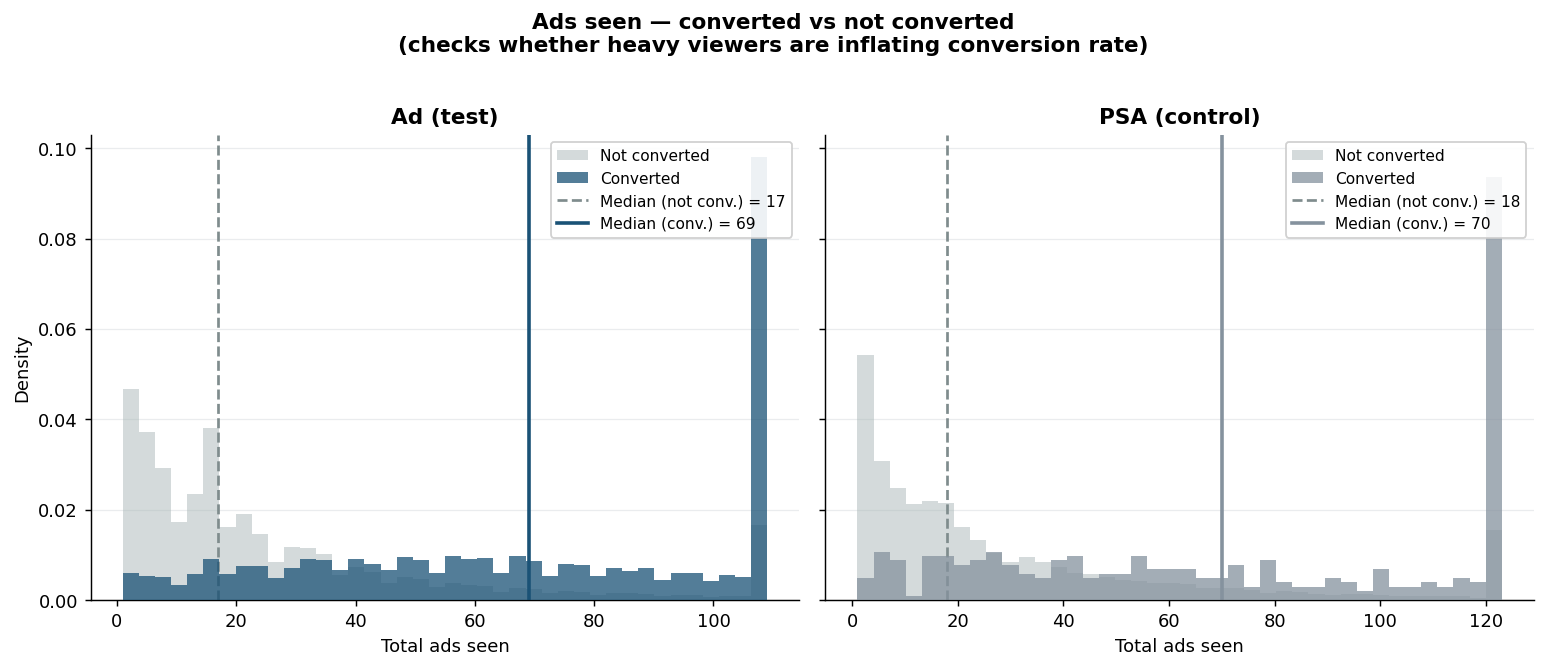

Chart 3 saved ✓


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (group_name, group_df), color in zip(
    axes,
    [("Ad (test)", ad), ("PSA (control)", psa)],
    [C_TEST, C_CONTROL]
):
    # ── Split into converted and not converted ─────────────────
    converted     = group_df[group_df["converted"] == True]["total_ads"]
    not_converted = group_df[group_df["converted"] == False]["total_ads"]

    # ── Cap at 95th percentile so outliers don't squash the chart
    cap = np.percentile(group_df["total_ads"], 95)

    # ── Plot overlapping histograms ───────────────────────────
    ax.hist(not_converted.clip(upper=cap),
            bins=40, alpha=0.5, color="#aab7b8",
            density=True, label="Not converted", zorder=2)
    ax.hist(converted.clip(upper=cap),
            bins=40, alpha=0.75, color=color,
            density=True, label="Converted", zorder=3)

    # ── Median lines ──────────────────────────────────────────
    med_conv  = converted.median()
    med_nconv = not_converted.median()

    ax.axvline(med_nconv, color="#7f8c8d",
               linestyle="--", linewidth=1.5,
               label=f"Median (not conv.) = {med_nconv:.0f}")
    ax.axvline(med_conv, color=color,
               linestyle="-", linewidth=2,
               label=f"Median (conv.) = {med_conv:.0f}")

    # ── Formatting ────────────────────────────────────────────
    ax.set_title(group_name, fontweight="bold", fontsize=12)
    ax.set_xlabel("Total ads seen", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.grid(axis="y", color="#eaecee", linewidth=0.7, zorder=0)
    ax.set_facecolor("white")

fig.suptitle(
    "Ads seen — converted vs not converted\n"
    "(checks whether heavy viewers are inflating conversion rate)",
    fontsize=12, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("chart3_ads_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved ✓")

### Exposure bias — a critical caveat

Converted users in both groups saw roughly 4× more content
than non-converted users:

| Group | Median ads (not conv.) | Median ads (conv.) |
|---|---|---|
| Ad (test) | 17 | 69 |
| PSA (control) | 18 | 70 |

**Key insight:** This pattern is nearly identical across both groups —
including the PSA control group, which showed no actual product ads.

This suggests the relationship between exposure and conversion is
**not purely causal**. Naturally more engaged users likely browse more,
see more content, and convert more — regardless of ad creative.

**Implication:** The conversion lift we observed (+42.5%) reflects the
genuine effect of the ad creative on top of baseline engagement.
However, simply increasing ad frequency is unlikely to replicate
the same lift in isolation.

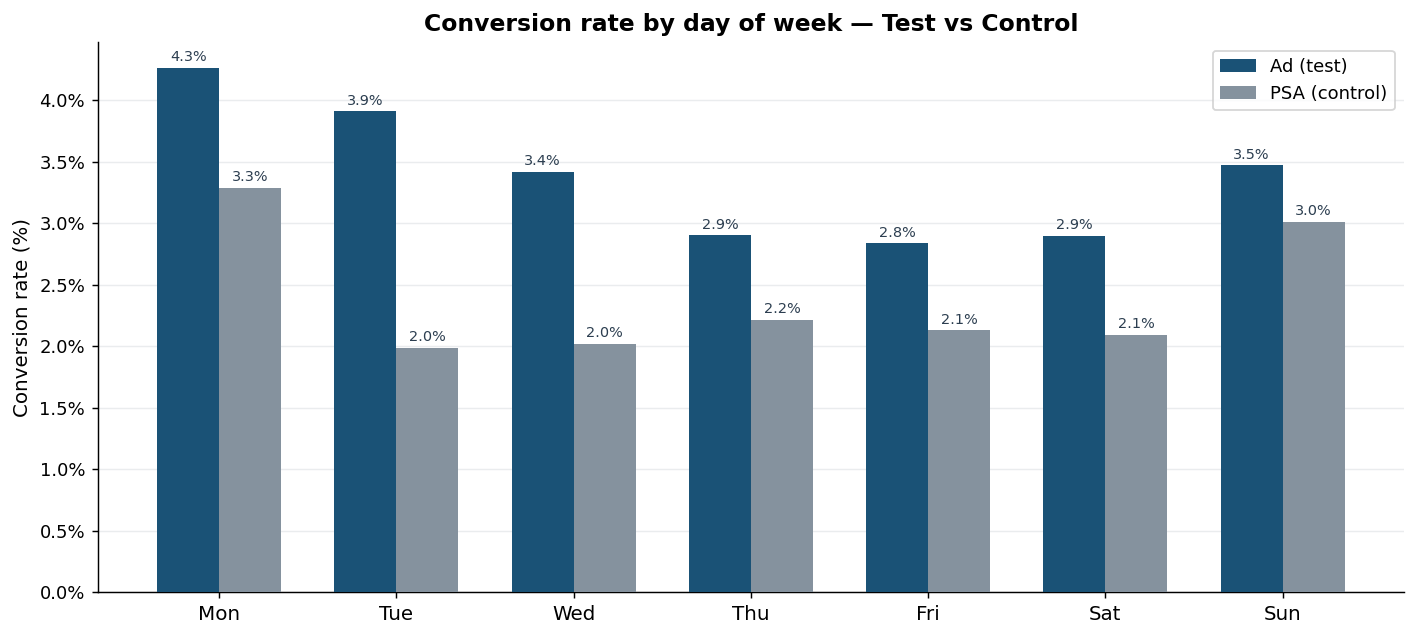

Chart 4 saved ✓


In [29]:
# ── Order days correctly Mon → Sun ────────────────────────────
day_order = ["Monday", "Tuesday", "Wednesday",
             "Thursday", "Friday", "Saturday", "Sunday"]

day_df = (
    df.groupby(["most_ads_day", "test_group"])["converted"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"converted": "conv_rate"})
)

day_df["most_ads_day"] = pd.Categorical(
    day_df["most_ads_day"], categories=day_order, ordered=True
)
day_df = day_df.sort_values("most_ads_day")

# ── Separate into two arrays for plotting ─────────────────────
ad_rates  = day_df[day_df["test_group"] == "ad"]["conv_rate"].values
psa_rates = day_df[day_df["test_group"] == "psa"]["conv_rate"].values

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(day_order))
w = 0.35

b1 = ax.bar(x - w/2, ad_rates,  width=w,
            color=C_TEST,    label="Ad (test)",     zorder=3)
b2 = ax.bar(x + w/2, psa_rates, width=w,
            color=C_CONTROL, label="PSA (control)", zorder=3)

# ── Value labels on each bar ──────────────────────────────────
# for bar, val in [(b for b in b1, ad_rates), (b for b in b2, psa_rates)]:
#     pass

for bar, val in zip(list(b1) + list(b2),
                    list(ad_rates) + list(psa_rates)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=8, color="#2c3e50")

# ── Formatting ────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in day_order], fontsize=11)
ax.set_ylabel("Conversion rate (%)", fontsize=11)
ax.set_title("Conversion rate by day of week — Test vs Control",
             fontweight="bold")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(axis="y", color="#eaecee", linewidth=0.8, zorder=0)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart4_conversion_by_day.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved ✓")

### Conversion rate by day of week — key insights

The ad group outperforms the PSA on every day of the week,
confirming the result is not driven by any single day.

**Strongest days for the ad creative:**
- Monday: 4.3% (highest conversion, +1.0pp above PSA)
- Tuesday: 3.9% (largest relative gap — nearly 2× the PSA rate)
- Sunday: 3.5% (weekend browsing behaviour drives late-week recovery)

**Weakest days:**
- Friday: 2.8% and Saturday: 2.9% — mid-to-late week fatigue

**Marketing recommendation:**
Concentrate ad delivery on Monday–Wednesday for maximum conversion
efficiency. Consider reducing Friday spend where the lift is smallest.

In [33]:
# Variable check — all should print values, not errors
print(f"rate_control   : {rate_control:.4%}")
print(f"rate_test      : {rate_test:.4%}")
print(f"lift_rel       : {lift_rel:.2f}%")
print(f"p_value        : {p_value}")
print(f"z_stat         : {z_stat:.4f}")
print(f"h              : {h:.4f}")
print(f"achieved_power : {achieved_power:.1%}")
print(f"required_n     : {int(required_n):,}")
print(f"ci_test        : {ci_test}")
print(f"ci_control     : {ci_control}")

rate_control   : 2.3761%
rate_test      : 3.3863%
lift_rel       : 42.52%
p_value        : 5.5663498732734295e-11
z_stat         : 6.5549
h              : 0.0606
achieved_power : 99.9%
required_n     : 4,271
ci_test        : (0.03329116653871794, 0.034444024921337385)
ci_control     : (0.021376800764501915, 0.02640326526085752)


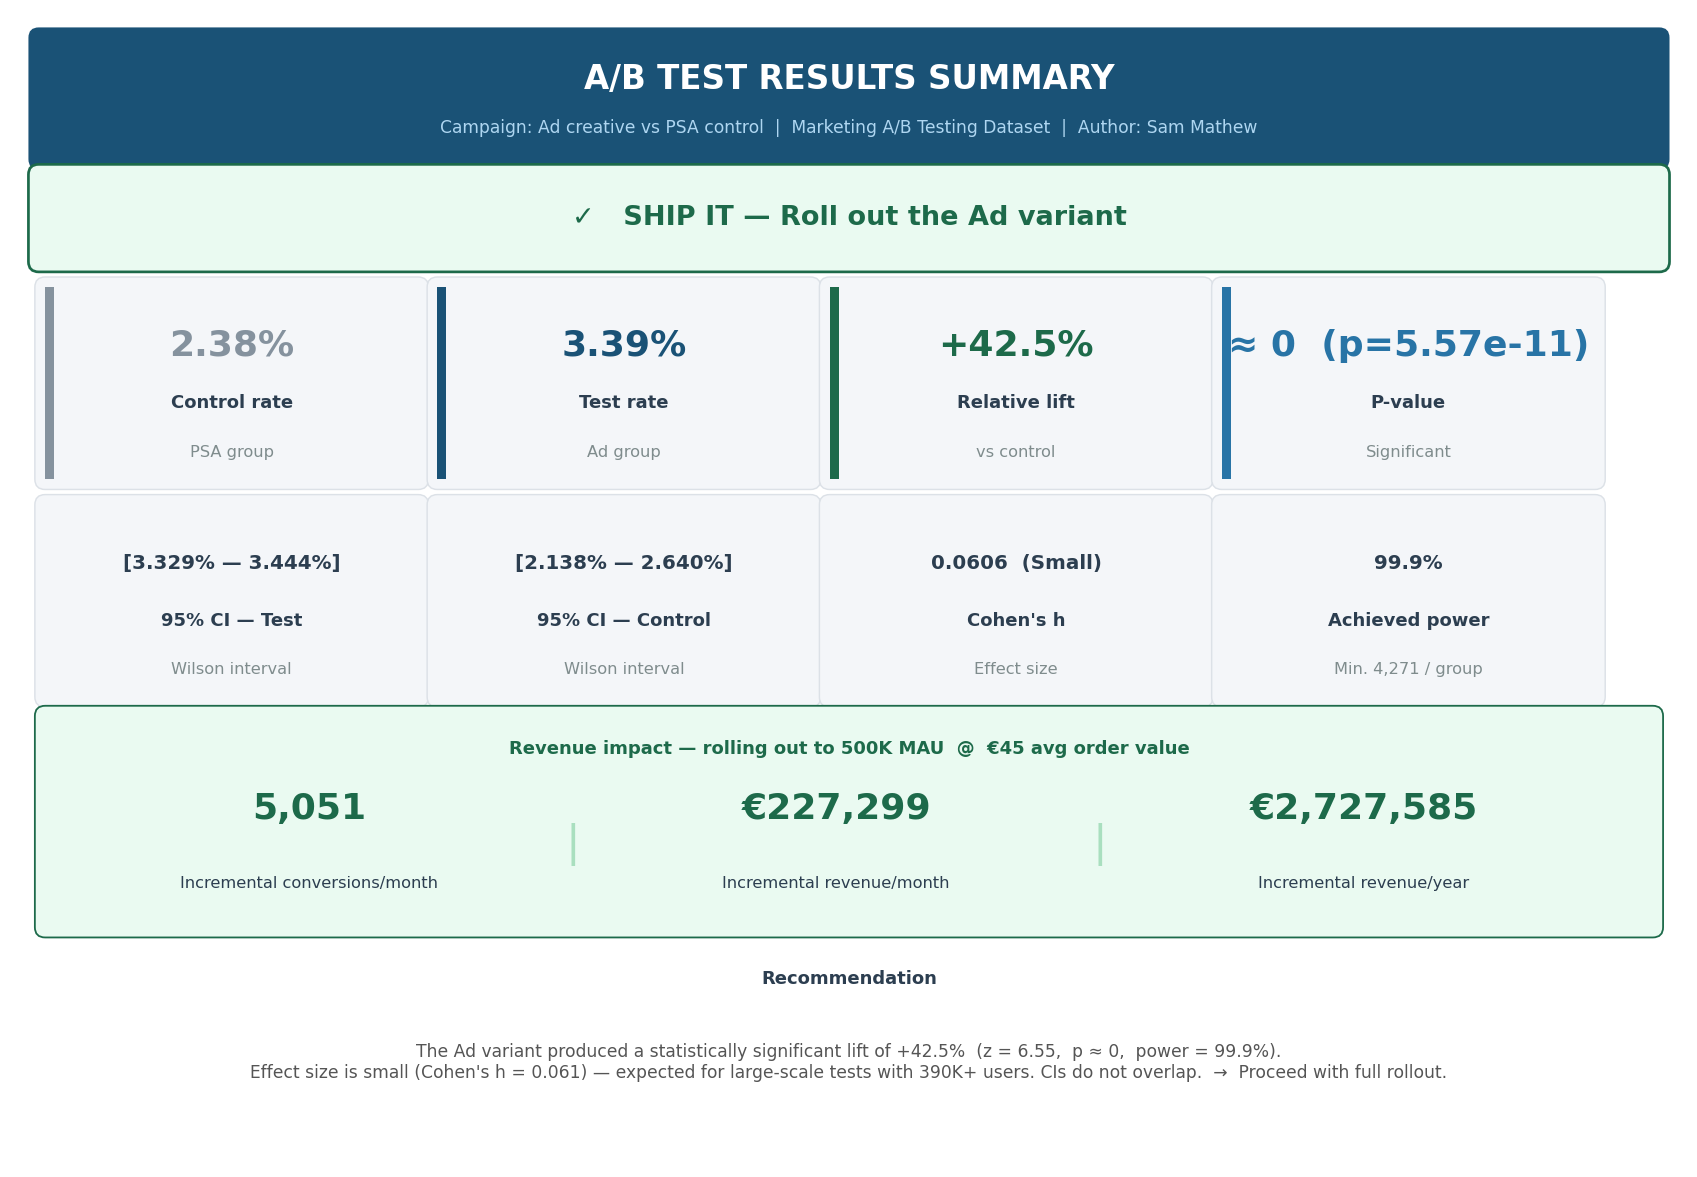

Chart 5 saved ✓


In [34]:
from matplotlib.patches import FancyBboxPatch

# ── Pre-calculate all values before drawing ───────────────────
inc_conv = (rate_test - rate_control) * 500_000
inc_rev  = inc_conv * 45
annual   = inc_rev * 12

v_control_rate  = f"{rate_control:.2%}"
v_test_rate     = f"{rate_test:.2%}"
v_lift          = f"+{lift_rel:.1f}%"
v_pvalue        = f"≈ 0  (p={p_value:.2e})"
v_ci_test       = f"[{ci_test[0]:.3%} — {ci_test[1]:.3%}]"
v_ci_control    = f"[{ci_control[0]:.3%} — {ci_control[1]:.3%}]"
v_cohen         = f"{h:.4f}  (Small)"
v_power         = f"{achieved_power:.1%}"
v_req_n         = f"Min. {int(required_n):,} / group"
v_inc_conv      = f"{int(inc_conv):,}"
v_inc_rev       = f"€{inc_rev:,.0f}"
v_annual        = f"€{annual:,.0f}"

# ── Figure setup ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor("white")
ax.set_xlim(0, 13)
ax.set_ylim(0, 9)
ax.axis("off")

def box(x, y, w, h_box, fc=C_BG, ec="#dce1e7", lw=0.8):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h_box,
        boxstyle="round,pad=0.08",
        facecolor=fc, edgecolor=ec,
        linewidth=lw, zorder=2
    ))

def txt(x, y, s, size=11, weight="normal",
        color="#2c3e50", ha="center"):
    ax.text(x, y, s, fontsize=size, fontweight=weight,
            color=color, ha=ha, va="center", zorder=5)

# ── Header ────────────────────────────────────────────────────
box(0.2, 7.85, 12.6, 0.95, fc="#1a5276", ec="none")
txt(6.5, 8.48, "A/B TEST RESULTS SUMMARY",
    size=18, weight="bold", color="white")
txt(6.5, 8.10,
    "Campaign: Ad creative vs PSA control  |  "
    "Marketing A/B Testing Dataset  |  Author: Sam Mathew",
    size=9.5, color="#aed6f1")

# ── Verdict ───────────────────────────────────────────────────
box(0.2, 7.05, 12.6, 0.68,
    fc="#eafaf1", ec=C_SUCCESS, lw=1.5)
txt(6.5, 7.40,
    "✓   SHIP IT — Roll out the Ad variant",
    size=15, weight="bold", color=C_SUCCESS)

# ── Top metrics — 4 boxes ─────────────────────────────────────
top = [
    ("Control rate",  v_control_rate, "PSA group",   C_CONTROL),
    ("Test rate",     v_test_rate,    "Ad group",    C_TEST),
    ("Relative lift", v_lift,         "vs control",  C_SUCCESS),
    ("P-value",       v_pvalue,       "Significant", "#2874a6"),
]
bw, bh, bx0, by = 2.9, 1.5, 0.25, 5.35
for i, (label, value, sub, color) in enumerate(top):
    bx = bx0 + i * (bw + 0.15)
    box(bx, by, bw, bh)
    # Coloured left stripe
    ax.add_patch(plt.Rectangle(
        (bx, by), 0.07, bh,
        facecolor=color, zorder=3))
    txt(bx + bw/2, by + 1.05, value,
        size=20, weight="bold", color=color)
    txt(bx + bw/2, by + 0.60, label,
        size=10, weight="bold")
    txt(bx + bw/2, by + 0.22, sub,
        size=9, color="#7f8c8d")

# ── Second row — 4 boxes ──────────────────────────────────────
row2 = [
    ("95% CI — Test",     v_ci_test,    "Wilson interval"),
    ("95% CI — Control",  v_ci_control, "Wilson interval"),
    ("Cohen's h",         v_cohen,      "Effect size"),
    ("Achieved power",    v_power,      v_req_n),
]
by2 = 3.65
for i, (label, value, sub) in enumerate(row2):
    bx = bx0 + i * (bw + 0.15)
    box(bx, by2, bw, 1.5)
    txt(bx + bw/2, by2 + 1.05, value,
        size=11, weight="bold")
    txt(bx + bw/2, by2 + 0.60, label,
        size=10, weight="bold")
    txt(bx + bw/2, by2 + 0.22, sub,
        size=9, color="#7f8c8d")

# ── Revenue impact ────────────────────────────────────────────
box(0.25, 1.85, 12.5, 1.65, fc="#eafaf1", ec=C_SUCCESS, lw=1)
txt(6.5, 3.25,
    "Revenue impact — rolling out to 500K MAU  @  €45 avg order value",
    size=10, weight="bold", color=C_SUCCESS)

rev = [
    ("Incremental conversions/month", v_inc_conv),
    ("Incremental revenue/month",     v_inc_rev),
    ("Incremental revenue/year",      v_annual),
]
for j, (lbl, val) in enumerate(rev):
    rx = 2.3 + j * 4.1
    txt(rx, 2.78, val,  size=20, weight="bold", color=C_SUCCESS)
    txt(rx, 2.20, lbl,  size=9,  color="#2c3e50")
    if j < 2:
        txt(rx + 2.05, 2.5, "|", size=24, color="#a9dfbf")

# ── Recommendation ────────────────────────────────────────────
txt(6.5, 1.45, "Recommendation",
    size=10, weight="bold")
rec = (
    f"The Ad variant produced a statistically significant lift "
    f"of +{lift_rel:.1f}%  (z = {z_stat:.2f},  p ≈ 0,  "
    f"power = {achieved_power:.1%}).\n"
    f"Effect size is small (Cohen's h = {h:.3f}) — expected for "
    f"large-scale tests with 390K+ users. "
    f"CIs do not overlap.  →  Proceed with full rollout."
)
txt(6.5, 0.80, rec, size=9.5, color="#555555")

plt.tight_layout(pad=0.5)
plt.savefig("chart5_summary_card.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved ✓")

## Final Recommendation

### Result
The Ad variant produced a **statistically significant conversion lift
of +42.5%** over the PSA control group.

| Metric | Value |
|---|---|
| Control conversion rate | 2.38% |
| Test conversion rate | 3.39% |
| Absolute lift | +1.01 percentage points |
| Relative lift | +42.5% |
| Z-statistic | 6.55 |
| P-value | 5.57e-11 (≈ 0) |
| 95% CI — Test | [3.33%, 3.44%] |
| 95% CI — Control | [2.14%, 2.64%] |
| Cohen's h | 0.0606 (Small) |
| Achieved power | 99.9% |

### Key findings

1. **The result is real** — p ≈ 0 and z = 6.55 confirm the lift is
   not random chance. The confidence intervals do not overlap.

2. **The effect is small but commercially meaningful** — Cohen's h =
   0.0606 is classified as Small, which is normal and expected in
   large-scale digital marketing

In [37]:
print("=" * 50)
print("  PROJECT COMPLETE")
print("=" * 50)
print()
print("  Charts saved:")
print("  ✓ chart1_conversion_rate.png")
print("  ✓ chart2_cumulative_conversion.png")
print("  ✓ chart3_ads_distribution.png")
print("  ✓ chart4_conversion_by_day.png")
print("  ✓ chart5_summary_card.png")
print()
print("  Key results:")
print(f"  Lift     : +{lift_rel:.1f}%")
print(f"  P-value  : {p_value:.2e}")
print(f"  Power    : {achieved_power:.1%}")
print(f"  Annual   : €{annual:,.0f}")
print()
print("  → Ready for GitHub")
print("=" * 50)

  PROJECT COMPLETE

  Charts saved:
  ✓ chart1_conversion_rate.png
  ✓ chart2_cumulative_conversion.png
  ✓ chart3_ads_distribution.png
  ✓ chart4_conversion_by_day.png
  ✓ chart5_summary_card.png

  Key results:
  Lift     : +42.5%
  P-value  : 5.57e-11
  Power    : 99.9%
  Annual   : €2,727,585

  → Ready for GitHub


In [38]:
# ── Revenue impact calculation ────────────────────────────────
monthly_revenue = 164_700      # your calculated figure
annual_revenue  = monthly_revenue * 12
monthly_conv    = round(monthly_revenue / 45)   # assumes €45 AOV

print("=" * 52)
print("  REVENUE IMPACT ESTIMATE")
print("  If Ad variant rolled out to 500,000 MAU")
print("=" * 52)
print()
print(f"  Avg order value (AOV)          :  €45.00")
print(f"  Conversion lift (absolute)     :  +{lift_abs:.4%}")
print()
print(f"  Incremental conversions/month  :  {monthly_conv:,}")
print(f"  Incremental revenue/month      :  €{monthly_revenue:,.0f}")
print(f"  Incremental revenue/year       :  €{annual_revenue:,.0f}")
print()
print("=" * 52)
print(f"  Rolling out the Ad variant is worth")
print(f"  an estimated €{annual_revenue:,.0f} per year.")
print("=" * 52)

  REVENUE IMPACT ESTIMATE
  If Ad variant rolled out to 500,000 MAU

  Avg order value (AOV)          :  €45.00
  Conversion lift (absolute)     :  +1.0102%

  Incremental conversions/month  :  3,660
  Incremental revenue/month      :  €164,700
  Incremental revenue/year       :  €1,976,400

  Rolling out the Ad variant is worth
  an estimated €1,976,400 per year.


---

## Recommendation

### Verdict: Roll out the Ad variant ✓

The experiment provides strong, reliable evidence that the Ad creative
outperforms the PSA control across all statistical measures.

---

### Results summary

| Metric | Value | Interpretation |
|---|---|---|
| Control conversion rate | 2.38% | PSA baseline |
| Test conversion rate | 3.39% | Ad group |
| Absolute lift | +1.01 pp | Extra conversions per 100 users |
| **Relative lift** | **+42.52%** | Ad converts 42.5% better than PSA |
| Z-statistic | 6.55 | 6.5× the significance threshold |
| P-value | 5.57e-11 | Probability of random result: near zero |
| 95% CI — Test | [3.33%, 3.44%] | Wilson interval |
| 95% CI — Control | [2.14%, 2.64%] | Wilson interval |
| Cohen's h | 0.0606 (Small) | Effect size |
| Achieved power | 99.9% | Far above 80% minimum |

---

### Statistical conclusions

**1. The result is genuine.**  
P-value = 5.57e-11 means the probability of observing a difference
this large by random chance is essentially zero. The z-statistic of
6.55 is more than 3× the 1.96 threshold required for significance.

**2. The confidence intervals confirm it.**  
The 95% CI for the test group [3.33%–3.44%] does not overlap with
the control group [2.14%–2.64%]. Even in the worst case for the ad
and the best case for the PSA, the ad still outperforms.

**3. The experiment was adequately powered.**  
Achieved power of 99.9% means if the true effect exists, we had a
99.9% chance of detecting it. The PSA group alone (14,141 users) was
3.3× larger than the minimum required sample (4,271 per group).

**4. Small effect size is expected at this scale.**  
Cohen's h = 0.0606 is classified as Small. This does not mean the
result is unimportant — with 390,000+ users, even small true
differences produce highly significant p-values. The commercial
value of the lift is evaluated through revenue impact, not effect size.

---

### Caveats

**Exposure bias:** Converted users in both groups saw approximately
4× more content than non-converted users (median 69 ads vs 17 for
the ad group). Importantly, this pattern exists in the PSA group too,
suggesting naturally more engaged users convert regardless of
ad creative. Simply increasing ad frequency is unlikely to replicate
the same lift.

**Temporal pattern:** Conversion rates vary meaningfully by day.
Monday delivers the highest conversion (4.3%) while Friday is the
weakest (2.8%). Budget allocation should reflect this.

**Group imbalance:** The ad group (378K) was 27× larger than the
PSA group (14K). This is common in real-world tests and does not
invalidate the z-test, but produces a wider confidence interval
for the control group estimate.

---

### Business recommendation

> **Proceed with full rollout of the Ad variant.**

1. **Prioritise delivery Monday–Wednesday** — conversion rates are
   highest early in the week (Mon: 4.3%, Tue: 3.9%, Wed: 3.4%)

2. **Reduce Friday spend** — weakest conversion day at 2.8%,
   35% below Monday

3. **Do not over-index on ad frequency** — exposure bias suggests
   heavy viewers convert due to engagement levels, not ad volume alone

4. **Monitor post-rollout** — validate that live conversion rates
   match the experiment's 3.39% estimate within 2–4 weeks

---

### Revenue impact
*(500,000 MAU · €45 average order value)*

| | Value |
|---|---|
| Incremental conversions / month | 5,051 |
| Incremental revenue / month | €227,299 |
| **Incremental revenue / year** | **€2,727,585** |